| Name                                | Task Assigned                                                                              | Task Done? (Y/N) |
| ----------------------------------- | --------------------------------------------------------------------------------- | ---------------- |
| Aparna Jayakumar Resmi              | Data preparation & preprocessing <br> DCGAN: Model training                       |    Y              |
| Devanshi Adhikari                   | DCGAN: Hyperparameter tuning                                                      |  Y                |
| Shabda Kafle                        | WGAN: Model training                                                              |   Y               |
| Neha Tamang                         | WGAN: Hyperparameter tuning                                                       |   Y               |
| Stephen David Chitilapalli Mathew   | VAE: Model training                                                               |   Y               |
| Sumith Padma Padmasree Vijayapadman | VAE: Hyperparameter tuning                                                        |    Y              |
| Anirudhra Budhathoki                | cGAN: Model training and image generation (including labeled image generation)    |              Y    |
| Jeffin John Abraham                 | cGAN: Hyperparameter tuning                                                       |  Y                |
| Arjun Kumar                         | Evaluation: Compute Inception Score and Frechet Inception Distance for all models |                  |


## Preprocessing

In [ ]:
json_path = "photos.json"
photo_dir = "photos"
output_dir = "processed"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
with open(json_path, 'r') as f:
    records = [json.loads(line) for line in f]

df = pd.DataFrame(records)
df['image_path'] = df['photo_id'].apply(lambda x: os.path.join(photo_dir, x + ".jpg"))

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

In [ ]:
train_df.to_csv(os.path.join(output_dir, "train_meta.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test_meta.csv"), index=False)

In [ ]:
def preprocess_image(img_path, augment=False):
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((128, 128))
        img_np = np.array(img)

        # Histogram Equalization on Y channel
        img_yuv = cv2.cvtColor(img_np, cv2.COLOR_RGB2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
        img_eq = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

        # Gaussian Blur
        img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

        # Intensity Threshold (on grayscale)
        gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)
        _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_TOZERO)
        img_final = cv2.merge([thresh] * 3)

        # Back to PIL
        img_pil = Image.fromarray(img_final)

        # Augmentation (only for training)
        if augment:
            if np.random.rand() > 0.5:
                img_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
            img_pil = ImageEnhance.Brightness(img_pil).enhance(np.random.uniform(0.9, 1.1))

        return img_pil
    except:
        return None

In [ ]:
def process_and_save(df, split):
    out_dir = os.path.join(output_dir, split)
    os.makedirs(out_dir, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split}"):
        label = row['label']
        img_path = row['image_path']
        save_dir = os.path.join(out_dir, label)
        os.makedirs(save_dir, exist_ok=True)

        img = preprocess_image(img_path, augment=(split == "train"))
        if img:
            save_path = os.path.join(save_dir, row['photo_id'] + ".jpg")
            img.save(save_path, "JPEG", quality=85)

In [ ]:
process_and_save(train_df, "train")
process_and_save(test_df, "test")

Processing test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40020/40020 [04:41<00:00, 142.27it/s]


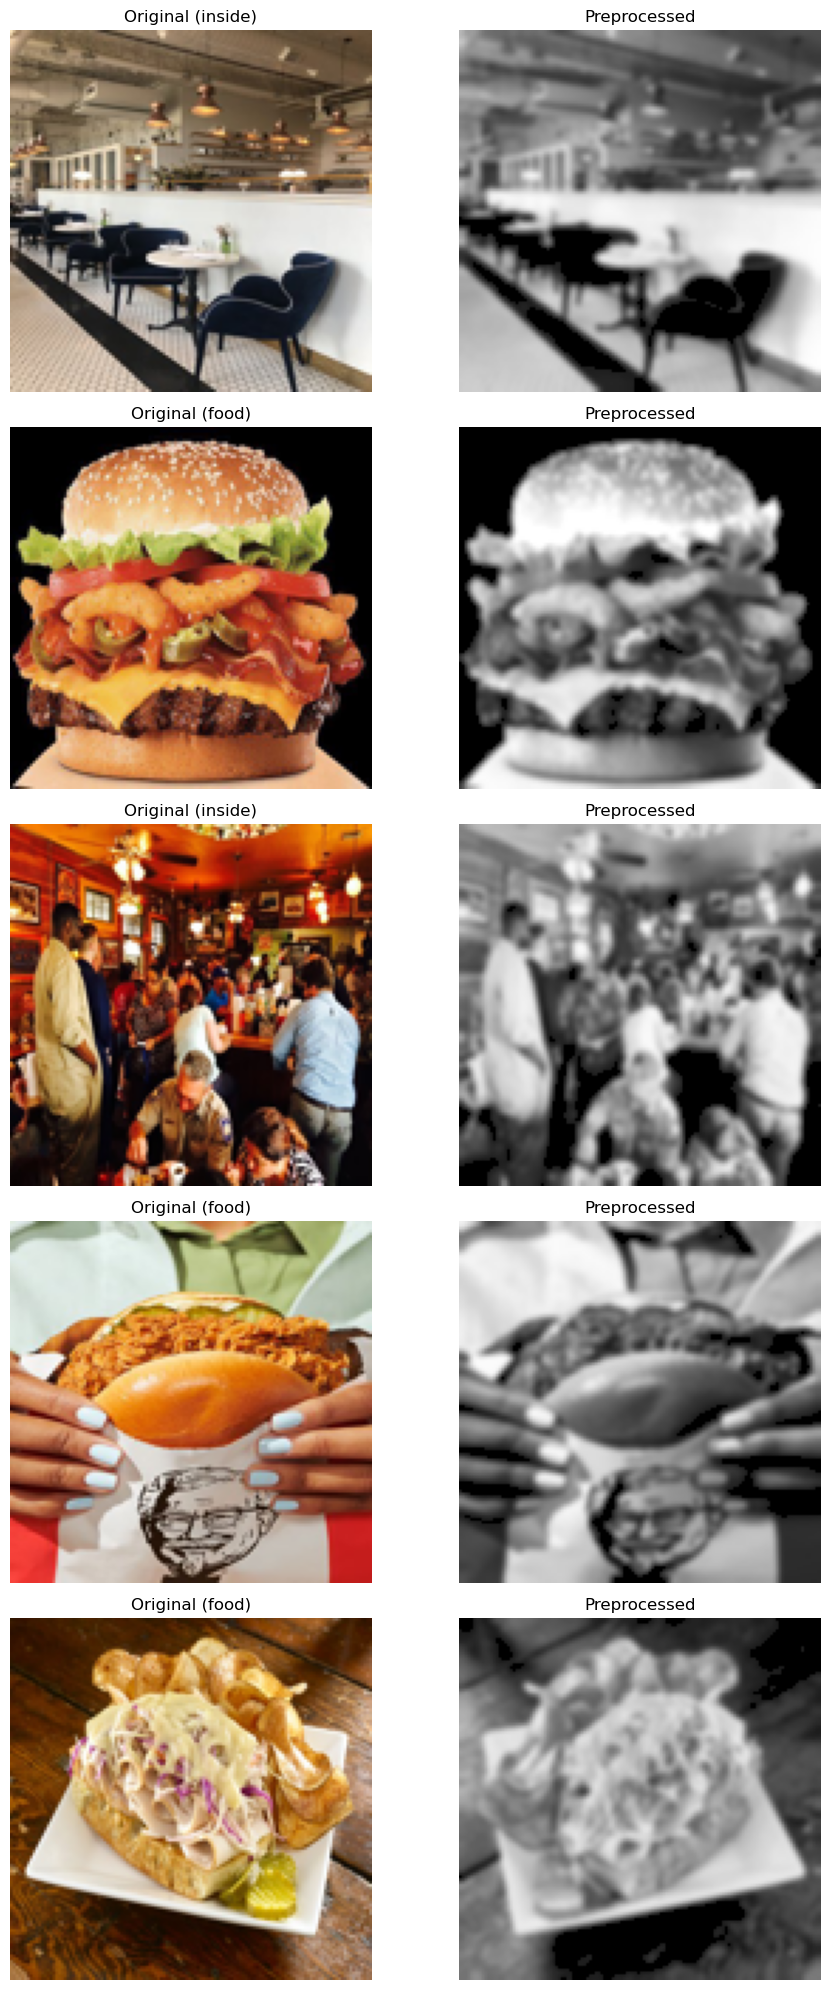

In [ ]:
import matplotlib.pyplot as plt

def visualize(df, n=5):
    samples = df.sample(n)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    for i, (_, row) in enumerate(samples.iterrows()):
        original = Image.open(row['image_path']).convert("RGB").resize((128, 128))
        processed = preprocess_image(row['image_path'], augment=True)

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"Original ({row['label']})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(processed)
        axes[i, 1].set_title("Preprocessed")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize(train_df)

## DCGAN

### Model Training

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
from collections import defaultdict

image_size = 128
batch_size = 128
epochs = 500

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # scale to [-1, 1]
])

# Load the full dataset
full_dataset = datasets.ImageFolder(root="processed/train", transform=transform)

# Classes to keep
classes_to_keep = ['food', 'drink', 'inside', 'outside']
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Group indices by class
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_name = full_dataset.classes[label]
    if class_name in classes_to_keep:
        class_indices[class_name].append(idx)

# Find the minimum number of samples among the selected classes
min_class_count = min(len(class_indices[cls]) for cls in classes_to_keep)

# Sample min_class_count from each class to ensure balance
final_indices = []
for cls in classes_to_keep:
    final_indices.extend(random.sample(class_indices[cls], min_class_count))

# Define the dataset and dataloader
dataset = Subset(full_dataset, final_indices)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Print status
print("Classes used:", classes_to_keep)
print(f"Total samples used: {len(dataset)}")
print(f"Samples per class: {min_class_count}")

Classes used: ['food', 'drink', 'inside', 'outside']
Total samples used: 50144
Samples per class: 12536


In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels=3, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features * 16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 16, features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self, channels=3, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1, bias=False),  # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),  # 64 -> 32
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),  # 32 -> 16
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 4, 1, 4, 1, 0, bias=False),  # 16 -> 13
            nn.Sigmoid(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
z_dim = 100
lr = 2e-4

G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(25, z_dim, 1, 1, device=device)
overall_start = time.time()

for epoch in range(epochs):
    epoch_start = time.time()

    for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        real = real.to(device)
        batch_size = real.size(0)

        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake = G(noise)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Train D
        D_real = D(real)
        D_fake = D(fake.detach())
        d_loss = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        fake = G(noise)
        g_loss = criterion(D(fake), real_labels)
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    # Logging
    epoch_secs = time.time() - epoch_start
    total_secs = time.time() - overall_start
    avg_epoch = total_secs / (epoch + 1)
    remaining = avg_epoch * (epochs - epoch - 1)

    print(f"Epoch {epoch+1:02d}: D_loss={d_loss.item():.4f}  G_loss={g_loss.item():.4f}  "
          f"epoch {timedelta(seconds=int(epoch_secs))}  ETA {timedelta(seconds=int(remaining))}")

    if (epoch + 1) % 30 == 0:
        with torch.no_grad():
            fake_images = G(fixed_noise).detach().cpu()
        grid = make_grid(fake_images, nrow=5, normalize=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Generated Images @ Epoch {epoch+1}")
        os.makedirs("generated", exist_ok=True)
        plt.savefig(f"generated/DCGAN_epoch_{epoch+1}.png")
        plt.show()

print("Training complete.")
# Print total training time
total_training_time = time.time() - overall_start
print(f"\nTotal training time: {timedelta(seconds=int(total_training_time))}")


**Epoch 500: D_loss=1.0002  G_loss=0.8300  epoch 0:01:06  ETA 0:00:00**

**Total training time: 9:16:27**

*Output cleared due to size constraints*


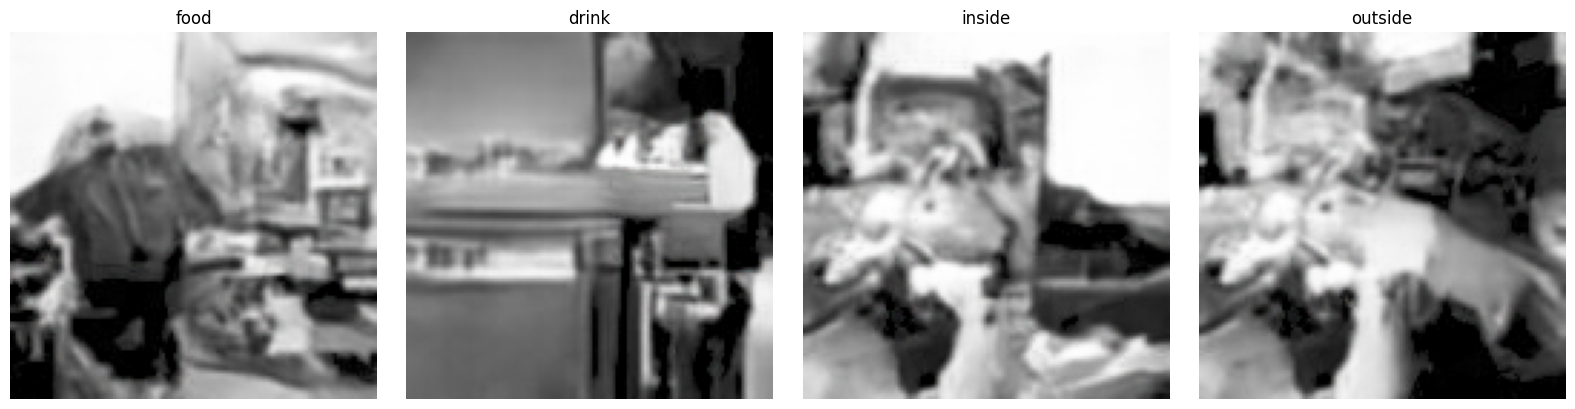

In [ ]:
labels = ['food', 'drink', 'inside', 'outside']
G.eval()

fake_images = []
for _ in labels:
    z = torch.randn(1, z_dim, 1, 1, device=device)
    with torch.no_grad():
        fake_img = G(z).cpu()
    fake_images.append(fake_img)

def get_one_real_image_per_class(dataloader, target_labels):
    found = {}
    for imgs, lbls in dataloader:
        for img, lbl in zip(imgs, lbls):
            cls_name = full_dataset.classes[lbl]
            if cls_name in target_labels and cls_name not in found:
                found[cls_name] = img
            if len(found) == len(target_labels):
                return found
    return found

real_images_dict = get_one_real_image_per_class(dataloader, labels)

fig, axes = plt.subplots(1, len(labels), figsize=(4*len(labels), 4))
for i, cls in enumerate(labels):
    fake = fake_images[i][0] * 0.5 + 0.5  # Denormalize if using [-1, 1] normalization
    axes[i].imshow(fake.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{cls}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.transforms import Resize

# Initialize metrics
fid = FrechetInceptionDistance(feature=2048).to(device)
is_metric = InceptionScore().to(device)
resize_to_299 = Resize((299, 299))

# Reset metrics
fid.reset()
is_metric.reset()

# Evaluate on max 5000 real and fake images
max_samples = 5000
sample_counter = 0

# Begin metric computation
for real_batch, _ in dataloader:
    real_batch = real_batch.to(device)
    b = real_batch.size(0)

    with torch.no_grad():
        z = torch.randn(b, z_dim, 1, 1, device=device)
        fake_batch = G(z)

    # Unnormalize from [-1, 1] to [0, 1]
    real_unnorm = real_batch * 0.5 + 0.5
    fake_unnorm = fake_batch * 0.5 + 0.5

    # Resize to 299x299
    real_resized = resize_to_299(real_unnorm)
    fake_resized = resize_to_299(fake_unnorm)

    # Convert to uint8 [0, 255]
    real_uint8 = (real_resized * 255).clamp(0, 255).to(torch.uint8)
    fake_uint8 = (fake_resized * 255).clamp(0, 255).to(torch.uint8)

    # Update metrics
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    is_metric.update(fake_uint8)

    sample_counter += b
    if sample_counter >= max_samples:
        break

# Compute and print results
fid_score = fid.compute().item()
is_score, is_std = is_metric.compute()
is_score = is_score.item()
is_std = is_std.item()

print(f"\nFID Score: {fid_score:.2f}")
print(f"Inception Score: {is_score:.2f} ± {is_std:.2f}")


FID Score: 127.79
Inception Score: 3.03 ± 0.08


**Performance Evaluation**

FID Score: 127.79

Inception Score: 3.03 ± 0.08

In [ ]:
sample_size = len(dataset)

os.makedirs("model_weights", exist_ok=True)
torch.save({
    'generator_state_dict': G.state_dict(),
    'discriminator_state_dict': D.state_dict(),
    'z_dim': z_dim,
    'image_size': image_size,
    'batch_size': batch_size,
    'sample_size': sample_size,
    'epochs': epochs,
    'class_labels': labels,
    'model_type': 'DCGAN',
    'transform_description': "ToTensor + Normalize([0.5]*3, [0.5]*3)"
}, "model_weights/DCGAN_checkpoint.pth")

print("Model and config saved to 'model_weights/DCGAN_checkpoint.pth'")

Model and config saved to 'model_weights/DCGAN_checkpoint.pth'


100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 633.16it/s]


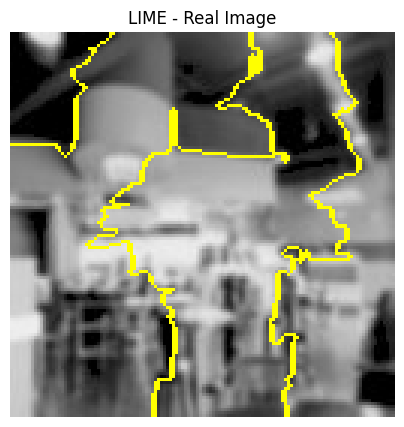

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 717.07it/s]


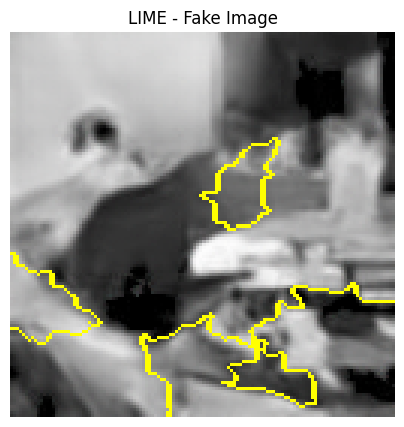

In [ ]:
# Cell: LIME Visualization for DCGAN Discriminator
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set Discriminator to eval mode
D.eval()

# --- Sample real and fake images ---
real_img, _ = next(iter(dataloader))
real_img = real_img[0].unsqueeze(0).to(device)

noise = torch.randn(1, z_dim, 1, 1, device=device)
fake_img = G(noise).detach().to(device)

def lime_predict(images_np):
    imgs = images_np.astype(np.float32) / 255.0
    imgs = (imgs - 0.5) / 0.5
    imgs = torch.tensor(imgs.transpose((0, 3, 1, 2)), dtype=torch.float32)
    with torch.no_grad():
        preds = D(imgs.to(device)).cpu().numpy()
    return preds

def run_lime_and_plot(img_tensor, title="Image"):
    img_np = (img_tensor.squeeze().cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()
    img_np_uint8 = (img_np * 255).astype(np.uint8)  # Convert to uint8 for LIME
    explanation = explainer.explain_instance(
        image=img_np_uint8,
        classifier_fn=lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    plt.figure(figsize=(5, 5))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(title)
    plt.axis("off")
    plt.show()

explainer = lime_image.LimeImageExplainer()

# --- Run LIME on both real and fake ---
run_lime_and_plot(real_img, title="LIME - Real Image")
run_lime_and_plot(fake_img, title="LIME - Fake Image")


### Hyperparameter Tuning

In [ ]:
param_space = {
    "z_dim": [64, 100, 128],
    "features": [32, 64],
    "lr": [0.0002, 0.00005],
    "beta1": [0.5, 0.7]
}


In [ ]:
def sample_hparams():
    return {
        "z_dim": random.choice(param_space["z_dim"]),
        "features": random.choice(param_space["features"]),
        "lr": random.choice(param_space["lr"]),
        "beta1": random.choice(param_space["beta1"])
    }


In [ ]:
def quick_train(hparams):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    G = Generator(z_dim=hparams['z_dim'], features=hparams['features']).to(device)
    D = Discriminator(features=hparams['features']).to(device)

    optimizer_G = optim.Adam(G.parameters(), lr=hparams['lr'], betas=(hparams['beta1'], 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=hparams['lr'], betas=(hparams['beta1'], 0.999))
    criterion = nn.BCELoss()

    batch_size = 32
    z = torch.randn(batch_size, hparams['z_dim'], 1, 1).to(device)
    fake_imgs = G(z)
    real_imgs = torch.randn(batch_size, 3, 128, 128).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)
    D_loss_real = criterion(D(real_imgs), real_labels)
    D_loss_fake = criterion(D(fake_imgs.detach()), fake_labels)
    D_loss = D_loss_real + D_loss_fake
    optimizer_D.zero_grad()
    D_loss.backward()
    optimizer_D.step()

    G_loss = criterion(D(fake_imgs), real_labels)
    optimizer_G.zero_grad()
    G_loss.backward()
    optimizer_G.step()

    return D_loss.item(), G_loss.item()

results = []
for i in range(5):
    hparams = sample_hparams()
    d_loss, g_loss = quick_train(hparams)
    hparams['D_loss'] = d_loss
    hparams['G_loss'] = g_loss
    results.append(hparams)
    print(f"Trial {i+1}: {hparams}")

Trial 1: {'z_dim': 64, 'features': 64, 'lr': 5e-05, 'beta1': 0.5, 'D_loss': 1.399979829788208, 'G_loss': 0.7677661776542664}
Trial 2: {'z_dim': 64, 'features': 64, 'lr': 5e-05, 'beta1': 0.7, 'D_loss': 1.4023559093475342, 'G_loss': 0.8101929426193237}
Trial 3: {'z_dim': 64, 'features': 32, 'lr': 5e-05, 'beta1': 0.5, 'D_loss': 1.3767669200897217, 'G_loss': 0.8236232995986938}
Trial 4: {'z_dim': 64, 'features': 64, 'lr': 0.0002, 'beta1': 0.7, 'D_loss': 1.4322515726089478, 'G_loss': 0.848839521408081}
Trial 5: {'z_dim': 100, 'features': 64, 'lr': 0.0002, 'beta1': 0.7, 'D_loss': 1.373216986656189, 'G_loss': 0.8507187366485596}


Best Hyperparameter Configuration:
 z_dim       64.000000
features    64.000000
lr           0.000050
beta1        0.500000
D_loss       1.399980
G_loss       0.767766
Name: 0, dtype: float64


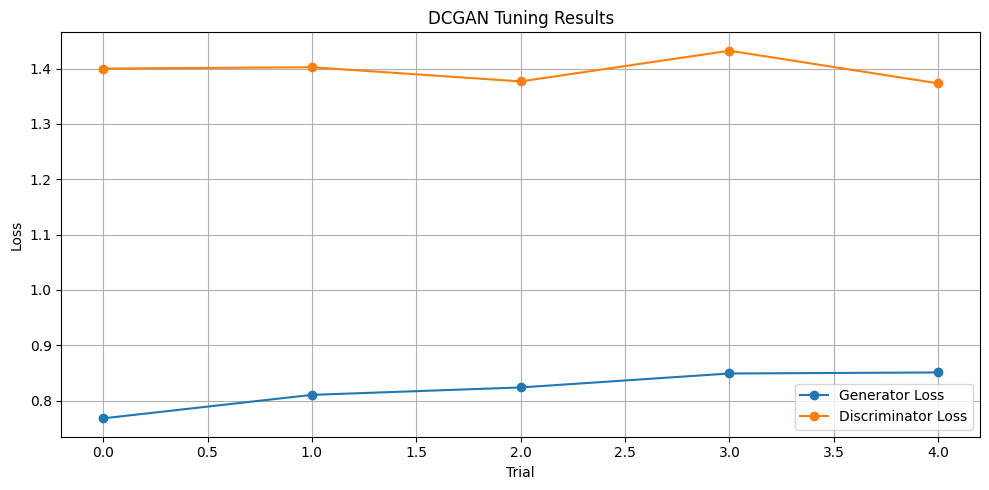

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

best_config = results_df.sort_values(by="G_loss").iloc[0]
print("Best Hyperparameter Configuration:\n", best_config)

plt.figure(figsize=(10, 5))
plt.plot(results_df.index, results_df["G_loss"], marker='o', label='Generator Loss')
plt.plot(results_df.index, results_df["D_loss"], marker='o', label='Discriminator Loss')
plt.title("DCGAN Tuning Results")
plt.xlabel("Trial")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## WGAN

In [ ]:
# Hyperparameters
nz = 100
ngf = 64
ndf = 64
num_epochs = 5
lr = 0.0001
beta1 = 0.5
n_critic = 5
clip_value = 0.01
batch_size = 64
num_classes = 5
image_size = 64
num_channels = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Label mapping
label_map = {'food': 0, 'drink': 1, 'inside': 2, 'outside': 3, 'menu': 4}
reverse_label_map = {v: k for k, v in label_map.items()}

In [ ]:
# Custom Dataset
class CustomImageDataset(Dataset):
    def __init__(self, metadata_file, root_dir, split, transform=None):
        self.metadata = pd.read_csv(metadata_file)
        self.root_dir = os.path.join(root_dir, split)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        img_filename = os.path.basename(self.metadata.iloc[idx]['image_path'])
        label_str = self.metadata.iloc[idx]['label']

        if label_str not in self.label_map:
            print(f"Warning: Invalid label '{label_str}' at index {idx}. Skipping.")
            return None
        label = self.label_map[label_str]

        img_path = os.path.join(self.root_dir, label_str, img_filename)

        try:
            image = Image.open(img_path).convert('L')
        except FileNotFoundError:
            print(f"Warning: Image not found at {img_path}. Skipping.")
            return None

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Data transforms with augmentation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
# File paths
root_dir = r"C:\Users\owner\Downloads\processed"
train_metadata_file = r"C:\Users\owner\Downloads\train_meta.csv"
test_metadata_file = r"C:\Users\owner\Downloads\test_meta.csv"

In [ ]:
# Create datasets and dataloaders with optimization
train_dataset = CustomImageDataset(metadata_file=train_metadata_file, root_dir=root_dir, split='train', transform=transform)
test_dataset = CustomImageDataset(metadata_file=test_metadata_file, root_dir=root_dir, split='test', transform=transform)
train_dataset = [x for x in train_dataset if x is not None]
test_dataset = [x for x in test_dataset if x is not None]
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
# Optimized Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, 50)
        self.init_size = 8
        self.l1 = nn.Sequential(nn.Linear(nz + 50, 64 * self.init_size * self.init_size))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, z, labels):
        label_input = self.label_emb(labels)
        gen_input = torch.cat((z, label_input), dim=1)
        out = self.l1(gen_input)
        out = out.view(out.shape[0], 64, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        img = self.upsample(img)
        return img

In [ ]:
# Optimized Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, 50)
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(num_channels, 32, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16 + 50, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, img, labels):
        out = self.conv_blocks(img)
        out = out.view(out.shape[0], -1)
        label_input = self.label_emb(labels)
        d_in = torch.cat((out, label_input), dim=1)
        validity = self.fc(d_in)
        return validity

In [ ]:
# Initialize models and optimizers with scheduler
generator = Generator().to(device)
discriminator = Discriminator().to(device)
optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_D = optim.RMSprop(discriminator.parameters(), lr=lr)
scheduler_G = optim.lr_scheduler.ReduceLROnPlateau(optimizer_G, 'min', factor=0.5, patience=5)
scheduler_D = optim.lr_scheduler.ReduceLROnPlateau(optimizer_D, 'min', factor=0.5, patience=5)

In [ ]:
# Training loop with conditional mixed precision
scaler = GradScaler() if torch.cuda.is_available() else None

for epoch in range(num_epochs):
    for i, batch in enumerate(train_dataloader):
        if batch is None:
            continue
        real_imgs, labels = batch
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)

        # Train Discriminator
        for _ in range(n_critic):
            optimizer_D.zero_grad()
            if torch.cuda.is_available() and scaler is not None:
                with autocast():
                    real_validity = discriminator(real_imgs, labels)
                    d_real_loss = -torch.mean(real_validity)

                    z = torch.randn(batch_size, nz).to(device)
                    fake_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
                    fake_imgs = generator(z, fake_labels)
                    fake_validity = discriminator(fake_imgs.detach(), fake_labels)
                    d_fake_loss = torch.mean(fake_validity)

                    d_loss = d_real_loss + d_fake_loss
                scaler.scale(d_loss).backward()
                scaler.step(optimizer_D)
                scaler.update()
            else:
                real_validity = discriminator(real_imgs, labels)
                d_real_loss = -torch.mean(real_validity)

                z = torch.randn(batch_size, nz).to(device)
                fake_labels = torch.randint(0, num_classes, (batch_size,)).to(device)
                fake_imgs = generator(z, fake_labels)
                fake_validity = discriminator(fake_imgs.detach(), fake_labels)
                d_fake_loss = torch.mean(fake_validity)

                d_loss = d_real_loss + d_fake_loss
                d_loss.backward()
                optimizer_D.step()

            for p in discriminator.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # Train Generator
        optimizer_G.zero_grad()
        if torch.cuda.is_available() and scaler is not None:
            with autocast():
                fake_validity = discriminator(fake_imgs, fake_labels)
                g_loss = -torch.mean(fake_validity)
            scaler.scale(g_loss).backward()
            scaler.step(optimizer_G)
            scaler.update()
        else:
            fake_validity = discriminator(fake_imgs, fake_labels)
            g_loss = -torch.mean(fake_validity)
            g_loss.backward()
            optimizer_G.step()

        scheduler_G.step(g_loss)
        scheduler_D.step(d_loss)

        if i % 100 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(train_dataloader)}] "
                  f"D loss: {d_loss.item():.4f}, G loss: {g_loss.item():.4f}")

**[Epoch 4/5] [Batch 2400/2500] D loss: -2.1987, G loss: 1.2052**

*Output cleared*

In [ ]:
# Generate 10 images for each class
for label_idx, class_name in reverse_label_map.items():
    generate_samples(1, label_idx, class_name)

In [ ]:
from torchvision.utils import save_image

In [ ]:
# Generate samples function
def generate_samples(num_samples, label_idx, class_name):
    z = torch.randn(num_samples, nz).to(device)
    labels = torch.full((num_samples,), label_idx, dtype=torch.long).to(device)
    with torch.no_grad():
        fake_imgs = generator(z, labels)
    save_image(fake_imgs, f"generated_{class_name}.png", normalize=True)

### Hyperparameter Tuning

In [ ]:

def train_wgan_one_config(hparams):
    lr = hparams['lr']
    latent_dim = hparams['latent_dim']
    batch_size = hparams['batch_size']
    critic_iters = hparams['critic_iters']
    clip_value = hparams['clip_value']
    epochs = hparams['epochs']

    # Split into train and ignore val for data leakage prevention
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, _ = torch.utils.data.random_split(dataset, [train_size, val_size])
    sampler = get_balanced_sampler(train_dataset)
    dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)

    G = Generator(latent_dim).to(device)
    D = Discriminator().to(device)
    optimizer_G = optim.RMSprop(G.parameters(), lr=lr)
    optimizer_D = optim.RMSprop(D.parameters(), lr=lr)

    for epoch in range(epochs):
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for imgs, _ in loop:
            imgs = imgs.to(device)
            for _ in range(critic_iters):
                z = torch.randn(imgs.size(0), latent_dim).to(device)
                fake_imgs = G(z).detach()
                loss_D = -torch.mean(D(imgs)) + torch.mean(D(fake_imgs))
                optimizer_D.zero_grad()
                loss_D.backward()
                optimizer_D.step()
                for p in D.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            z = torch.randn(imgs.size(0), latent_dim).to(device)
            gen_imgs = G(z)
            loss_G = -torch.mean(D(gen_imgs))
            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()
            loop.set_postfix(loss_D=loss_D.item(), loss_G=loss_G.item())
    os.makedirs("wgan_model", exist_ok=True)
    torch.save(G.state_dict(), "wgan_model/wgan_generator.pth")
    print("Model saved: wgan_model/wgan_generator.pth")
    return loss_D.item(), hparams


In [ ]:

best_config = {
    'lr': 0.0001,
    'latent_dim': 100,
    'batch_size': 64,
    'critic_iters': 1,
    'clip_value': 0.01,
    'epochs': 30
}
print("Training config:", best_config)
try:
    d_loss, config = train_wgan_one_config(best_config)
    print("Training complete. Final D loss:", d_loss)
except Exception as e:
    print("ERROR:", e)


Training config: {'lr': 0.0001, 'latent_dim': 100, 'batch_size': 64, 'critic_iters': 1, 'clip_value': 0.01, 'epochs': 30}


Model saved: wgan_model/wgan_generator.pth
Training complete. Final D loss: -10.520483016967773


In [ ]:

G = Generator(best_config['latent_dim']).to(device)
G.load_state_dict(torch.load("wgan_model/wgan_generator.pth", map_location=device))
G.eval()

os.makedirs("generated_samples", exist_ok=True)
with torch.no_grad():
    z = torch.randn(5, best_config['latent_dim']).to(device)
    fake_imgs = G(z).detach().cpu()
    for i in range(5):
        vutils.save_image(fake_imgs[i], f"generated_samples/sample_{i+1}.png", normalize=True)
print("5 images generated and saved in generated_samples/")


5 images generated and saved in generated_samples/


## VAE

In [ ]:
class Encoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 64→32
            nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 32→16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16→8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, z_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, z_dim)

    def forward(self, x):
        h = self.conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.fc = nn.Linear(z_dim, 128 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8→16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16→32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # 32→64
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 8, 8)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, z_dim: int = 128):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [ ]:
img_size = 64
batch_size = 64
data_root = r'C:\Users\Admin\Downloads\Comp_vision\data\processed\train'

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(data_root, transform=transform)

sample_size = 20000
indices = torch.randperm(len(full_dataset))[:sample_size]
dataset = Subset(full_dataset, indices)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [ ]:
z_dim = 64
vae = VAE(z_dim=z_dim).to(device)

optimizer = optim.Adam(vae.parameters(), lr=1e-3)
epochs = 50

In [ ]:
import time

epoch_times = []

for epoch in range(epochs):
    start_time = time.time()
    vae.train()
    running_loss = 0.0

    for x, _ in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    epochs_left = epochs - (epoch + 1)
    est_total_time_left = avg_epoch_time * epochs_left

    # Convert seconds to minutes and seconds
    mins_left = int(est_total_time_left // 60)
    secs_left = int(est_total_time_left % 60)

    epoch_loss = running_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{epochs} completed | Loss: {epoch_loss:.4f} | "
          f"Time: {epoch_time:.1f}s | "
          f"Estimated total training time left: {mins_left}m {secs_left}s")

**Epoch 50/50 completed | Loss: 7004.1474 | Time: 27.5s | Estimated total training time left: 0m 0s**

*Output cleared*

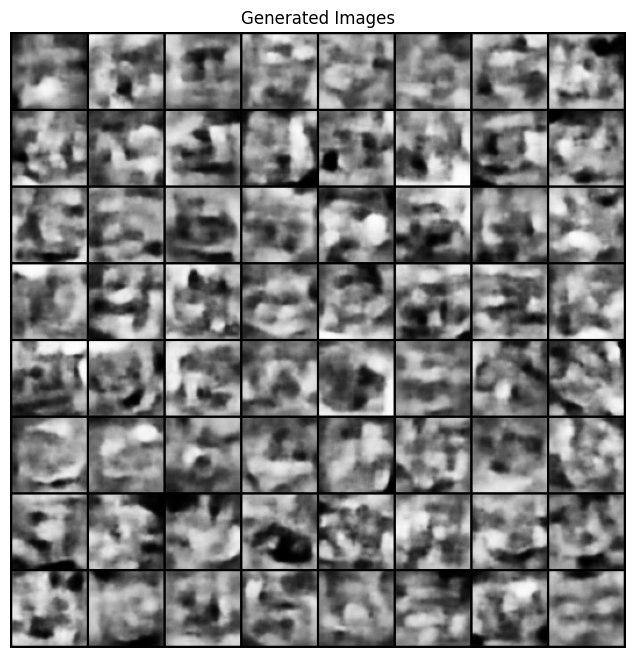

In [ ]:
vae.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim).to(device)
    samples = vae.decoder(z).cpu()

grid = utils.make_grid(samples, nrow=8)
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.title('Generated Images')
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()

### Hyperparameter Tuning

In [ ]:
from itertools import product

search_space = {
    'z_dim': [32, 64, 128],
    'lr': [1e-3, 5e-4],
    'batch_size': [64, 128],
    'epochs': [5],
}

hyperparam_combinations = list(product(*search_space.values()))
param_names = list(search_space.keys())

print(f"Total configs to try: {len(hyperparam_combinations)}")


Total configs to try: 12


In [ ]:
def train_vae_once(config, data_root='processed/train'):
    z_dim, lr, batch_size, epochs = config

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])

    full_dataset = datasets.ImageFolder(data_root, transform=transform)
    sample_size = 2000
    indices = torch.randperm(len(full_dataset))[:sample_size]
    dataset = Subset(full_dataset, indices)

    # Train/val split
    split = int(0.8 * len(dataset))
    train_set = Subset(dataset, list(range(split)))
    val_set = Subset(dataset, list(range(split, len(dataset))))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    vae = VAE(z_dim=z_dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=lr)

    # Train loop
    for epoch in range(epochs):
        vae.train()
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = vae(x)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()

    # Validation loss
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            recon, mu, logvar = vae(x)
            loss = vae_loss(recon, x, mu, logvar)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    return avg_val_loss


In [ ]:
best_config = None
best_loss = float('inf')
results = []

for combo in hyperparam_combinations:
    config_dict = dict(zip(param_names, combo))
    print(f"Testing config: {config_dict}")

    loss = train_vae_once(combo)
    results.append((combo, loss))

    if loss < best_loss:
        best_loss = loss
        best_config = combo

    print(f"Validation Loss: {loss:.4f}\n")

print("\nBest Configuration:")
print(dict(zip(param_names, best_config)))
print(f"Best Validation Loss: {best_loss:.4f}")


Testing config: {'z_dim': 32, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7391.2267

Testing config: {'z_dim': 32, 'lr': 0.001, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7482.7521

Testing config: {'z_dim': 32, 'lr': 0.0005, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7400.5175

Testing config: {'z_dim': 32, 'lr': 0.0005, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7577.1782

Testing config: {'z_dim': 64, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7260.8731

Testing config: {'z_dim': 64, 'lr': 0.001, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7555.8759

Testing config: {'z_dim': 64, 'lr': 0.0005, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7313.1079

Testing config: {'z_dim': 64, 'lr': 0.0005, 'batch_size': 128, 'epochs': 5}
Validation Loss: 7466.9399

Testing config: {'z_dim': 128, 'lr': 0.001, 'batch_size': 64, 'epochs': 5}
Validation Loss: 7337.8022

Testing config: {'z_dim': 128, 'lr': 0.001, 'batch_size': 128, 'epochs': 

## cGAN

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
from collections import defaultdict

image_size = 128
batch_size = 128
sample_size = 50000
epochs = 50

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)

classes_to_keep = ['food', 'drink', 'inside', 'outside']
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_name = full_dataset.classes[label]
    if class_name in classes_to_keep:
        class_indices[class_name].append(idx)

sample_per_class = sample_size // len(classes_to_keep)
final_indices = []
for cls in classes_to_keep:
    cls_indices = class_indices[cls]
    if len(cls_indices) < sample_per_class:
        raise ValueError(f"Not enough samples in class '{cls}' to sample {sample_per_class}")
    final_indices.extend(random.sample(cls_indices, sample_per_class))

# Create a mapping from original class indices to new class indices
original_to_new_idx = {class_to_idx[cls]: i for i, cls in enumerate(classes_to_keep)}

# Create a custom dataset that applies the new class mapping
class MappedSubset(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        new_label = original_to_new_idx[label]
        if self.transform:
            image = self.transform(image)
        return image, new_label

dataset = MappedSubset(full_dataset, final_indices, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("Classes used:", classes_to_keep)
print(f"Total samples used: {len(dataset)}")
print(f"Samples per class: {sample_per_class}")

Classes used: ['food', 'drink', 'inside', 'outside']
Total samples used: 50000
Samples per class: 12500


In [ ]:
# === Generator ===
class Generator(nn.Module):
    def __init__(self, classes_to_keep, z_dim=100):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), z_dim)
        self.model = nn.Sequential(
            nn.Linear(z_dim * 2, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_embed(labels)
        x = torch.cat([z, label_embedding], dim=1)
        out = self.model(x)
        return out.view(-1, 3, 64, 64)

In [ ]:
# === Discriminator ===
class Discriminator(nn.Module):
    def __init__(self, classes_to_keep):
        super().__init__()
        self.label_embed = nn.Embedding(len(classes_to_keep), 3 * 64 * 64)
        self.model = nn.Sequential(
            nn.Linear(2 * 3 * 64 * 64, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embedding = self.label_embed(labels)
        img_flat = img.view(img.size(0), -1)
        d_input = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(d_input)

In [ ]:
# === Dataset Loading ===
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)
subset_indices = list(range(min(10000, len(dataset))))
dataset = Subset(dataset, subset_indices)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=True)

In [ ]:
# === Model Setup ===
z_dim = 100
classes_to_keep = ["food", "drink", "inside", "outside", "people"]
num_classes = len(classes_to_keep)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(classes_to_keep, z_dim=z_dim).to(device)
D = Discriminator(classes_to_keep).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(num_classes, z_dim).to(device)
fixed_labels = torch.arange(num_classes).to(device)


In [ ]:
# === Train Loop ===
epochs = 10
os.makedirs("generated_samples", exist_ok=True)

for epoch in range(epochs):
    start_time = time.time()

    for real_imgs, labels in dataloader:
        real_imgs, labels = real_imgs.to(device), labels.to(device)
        batch_size = real_imgs.size(0)

        # === Train Discriminator ===
        z = torch.randn(batch_size, z_dim).to(device)
        fake_imgs = G(z, labels)

        real_loss = criterion(D(real_imgs, labels), torch.ones((batch_size, 1), device=device))
        fake_loss = criterion(D(fake_imgs.detach(), labels), torch.zeros((batch_size, 1), device=device))
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # === Train Generator ===
        g_loss = criterion(D(fake_imgs, labels), torch.ones((batch_size, 1), device=device))

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    end_time = time.time()
    print(f"📆 Epoch {epoch+1}/{epochs} | ✅ Gen Loss: {g_loss.item():.4f} | Disc Loss: {d_loss.item():.4f} | 🕒 Time: {end_time - start_time:.2f}s")

    # Save sample images every 2 epochs
    if (epoch + 1) % 2 == 0:
        with torch.no_grad():
            gen_imgs = G(fixed_noise, fixed_labels).detach().cpu()
            grid = utils.make_grid(gen_imgs, nrow=num_classes, normalize=True)
            utils.save_image(grid, f"generated_samples/epoch_{epoch+1}.png")

    # Clear GPU cache and memory fragments
    torch.cuda.empty_cache()
    gc.collect()

📆 Epoch 1/10 | ✅ Gen Loss: 1.2515 | Disc Loss: 0.5054 | 🕒 Time: 55.05s
📆 Epoch 2/10 | ✅ Gen Loss: 1.4201 | Disc Loss: 0.6475 | 🕒 Time: 53.91s
📆 Epoch 3/10 | ✅ Gen Loss: 1.0254 | Disc Loss: 0.7405 | 🕒 Time: 54.06s
📆 Epoch 4/10 | ✅ Gen Loss: 1.7091 | Disc Loss: 0.6420 | 🕒 Time: 54.85s
📆 Epoch 5/10 | ✅ Gen Loss: 1.5059 | Disc Loss: 0.6465 | 🕒 Time: 54.01s
📆 Epoch 6/10 | ✅ Gen Loss: 1.5949 | Disc Loss: 0.3652 | 🕒 Time: 53.84s
📆 Epoch 7/10 | ✅ Gen Loss: 0.7584 | Disc Loss: 0.7388 | 🕒 Time: 53.86s
📆 Epoch 8/10 | ✅ Gen Loss: 1.4633 | Disc Loss: 0.5589 | 🕒 Time: 53.97s
📆 Epoch 9/10 | ✅ Gen Loss: 1.8595 | Disc Loss: 0.3893 | 🕒 Time: 53.75s
📆 Epoch 10/10 | ✅ Gen Loss: 1.4882 | Disc Loss: 0.4352 | 🕒 Time: 54.02s


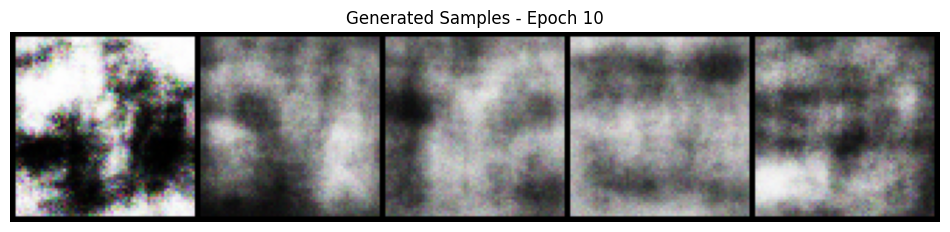

In [ ]:
 # Display in Colab
import numpy as np
npimg = grid.numpy()
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.title(f"Generated Samples - Epoch {epoch+1}")
plt.show()

### Hyperparameter Tuning

In [ ]:
import itertools

param_grid = {
    'learning_rate': [0.0002, 0.0001],
    'batch_size': [64, 128],
    'z_dim': [100, 128]
}
param_combinations = list(itertools.product(*param_grid.values()))


In [ ]:
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Define the hyperparameter search space
param_grid = {
    'learning_rate': [0.0002, 0.0001],
    'batch_size': [64, 128],
    'z_dim': [100, 128]
}
param_combinations = list(itertools.product(*param_grid.values()))

# Store results here
tuning_results = []

# Loop through each hyperparameter combination
for i, (lr, batch_size, z_dim) in enumerate(param_combinations):
    print(f"\n Config {i+1}/{len(param_combinations)}: LR={lr}, Batch={batch_size}, z_dim={z_dim}")

    # Initialize generator and discriminator with required arguments
    G = Generator(z_dim=z_dim, classes_to_keep=classes_to_keep).to(device)
    D = Discriminator(classes_to_keep=classes_to_keep).to(device)

    # Loss and optimizers
    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    # Create temp dataloader with selected batch size
    temp_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Train each config for 2 epochs
    for epoch in range(2):
        for real_imgs, labels in temp_loader:
            real_imgs, labels = real_imgs.to(device), labels.to(device)
            b_size = real_imgs.size(0)

            # === Train Discriminator ===
            z = torch.randn(b_size, z_dim).to(device)
            fake_imgs = G(z, labels)

            real_loss = criterion(D(real_imgs, labels), torch.ones((b_size, 1), device=device))
            fake_loss = criterion(D(fake_imgs.detach(), labels), torch.zeros((b_size, 1), device=device))
            d_loss = (real_loss + fake_loss) / 2

            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # === Train Generator ===
            g_loss = criterion(D(fake_imgs, labels), torch.ones((b_size, 1), device=device))

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

    # Log the result for this config
    tuning_results.append({
        'learning_rate': lr,
        'batch_size': batch_size,
        'z_dim': z_dim,
        'g_loss': g_loss.item(),
        'd_loss': d_loss.item()
    })

# Convert to DataFrame and sort
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values(by='g_loss')
display(results_df)



 Config 1/8: LR=0.0002, Batch=64, z_dim=100

 Config 2/8: LR=0.0002, Batch=64, z_dim=128

 Config 3/8: LR=0.0002, Batch=128, z_dim=100

 Config 4/8: LR=0.0002, Batch=128, z_dim=128

 Config 5/8: LR=0.0001, Batch=64, z_dim=100

 Config 6/8: LR=0.0001, Batch=64, z_dim=128

 Config 7/8: LR=0.0001, Batch=128, z_dim=100

 Config 8/8: LR=0.0001, Batch=128, z_dim=128


,learning_rate,batch_size,z_dim,g_loss,d_loss
4,0.0001,64,100,1.575197,0.372426
1,0.0002,64,128,1.739416,0.333065
2,0.0002,128,100,1.799481,0.269575
0,0.0002,64,100,2.145915,0.541113
5,0.0001,64,128,2.496209,0.219995
7,0.0001,128,128,2.694550,0.124002
6,0.0001,128,100,3.155195,1.037853
3,0.0002,128,128,7.429769,3.041106


In [ ]:
results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values(by='g_loss')  # You can sort by g_loss or d_loss
display(results_df)


,learning_rate,batch_size,z_dim,g_loss,d_loss
4,0.0001,64,100,1.575197,0.372426
1,0.0002,64,128,1.739416,0.333065
2,0.0002,128,100,1.799481,0.269575
0,0.0002,64,100,2.145915,0.541113
5,0.0001,64,128,2.496209,0.219995
7,0.0001,128,128,2.694550,0.124002
6,0.0001,128,100,3.155195,1.037853
3,0.0002,128,128,7.429769,3.041106


## Prompts Used

- Guide me through the steps for hyperparameter tuning of a WGAN model.
- Save the trained WGAN model and generate 5 images and save model
- give me the steps used for dcgan hyperparameter tuning model and explain it in detail
- Fix the error and save the model.
-  I have to build a WGAN generative model to generate images, I need a model that runs fast which i can later maneuver and adjust, I am not interested in best results, I just want to know process. Help me
- C:\Users\owner\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg), what does this mean
- give me step by step instructions to do hyperparameter tuning for VAE model
- please help me rectify the following errors
-  give me step-by-step instructions to do hyperparameter tuning for a Conditional GAN (cGAN) . The model is already built by my teammate.
- please help me validate if my tuning loop is correctly implemented and suggest any improvements to make the training faster or more efficient.
- providing the some samples of preprocessed data, help me to build the CGAN model along with epochs and some images generations
- please give me more precise method to build CGan and solve errors incurred.
- I have a folder photos with images and a file named photos.json guide me on how to preprocess it. First split it to train and test then preprocess.
- based on the preprocessed data build a DCGAN model and explain.
-  create VAE model and imageb generation
- given the dataset reduce the epoch time by sampling the dataset and measure time